# Neural HSP: Conceitualização e Validação de Hipóteses

Este notebook inicia a transição formal do modelo estocástico de Monte Carlo (Sprint 1) para o modelo de Operadores Neurais Contínuos e Flow Matching (Sprint 2).

## Resumo das Hipóteses (Neural HSP)

1. **Hipótese da Aproximação de Acessibilidade (NPE):** Podemos aprender um operador $q_\phi(S_t | x_t)$ que mapeia estados $x_t$ diretamente para a probabilidade de sobrevivência na bacia ($S_t$), contornando integrações longas de Monte Carlo no espaço da fase regular.
2. **Hipótese de Regularização Geométrica (OT-CFM):** O uso de **Optimal Transport Conditional Flow Matching** como prior/loss dinâmica impõe que o mapeamento latente não apenas ajuste os dados, mas siga um mapa de fluxo contínuo e suave, preservando a coerência topológica da Vizinhança da Bacia de Atração.
3. **Eficiência no Mundo Real (RW):** A inferência desse Score via JAX/Equinox ocorrerá em $O(1)$ ou $O(K)$, permitindo scale-up para datasets estruturais massivos (ex: falhas em motores, redes elétricas) onde as métricas tradicionais (Variância, AC1) e MC convencional falham.

In [9]:
%pip install optax

Note: you may need to restart the kernel to use updated packages.


In [10]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import seaborn as sns

from jax import random
from typing import Callable

sns.set_theme(style="whitegrid")
key = random.PRNGKey(42)

### 1. Definição do Operador (O Campo Vetorial contínuo)
Conforme inspecionamos no `gwax` e nas fundações do JAX, construiremos uma MLP condicionada no tempo $t$ para atuar como nosso Vetor de Fluxo contínuo $v_\theta(t, x)$.

In [11]:
class ContinuousViabilityOperator(eqx.Module):
    """
    Operador Parametrizado: Mapeia (t, x) -> v(t, x)
    """
    mlp: eqx.nn.MLP

    def __init__(self, state_dim: int, hidden_size: int, depth: int, key: jax.random.PRNGKey):
        # Injeta time (1) + state (state_dim)
        self.mlp = eqx.nn.MLP(
            in_size=state_dim + 1,
            out_size=state_dim,
            width_size=hidden_size,
            depth=depth,
            activation=jax.nn.gelu,
            key=key
        )

    def __call__(self, t: float, x: jax.Array) -> jax.Array:
        t_arr = jnp.atleast_1d(t)
        h = jnp.concatenate([t_arr, x], axis=-1)
        return self.mlp(h)

# Inicializando a rede
key, subkey = random.split(key)
state_dim = 2 # Exemplo: Espaço 2D para visualizarmos a bacia real
model = ContinuousViabilityOperator(state_dim=state_dim, hidden_size=64, depth=3, key=subkey)
print(f"Modelo base inicializado com {sum(x.size for x in jax.tree_util.tree_leaves(model) if eqx.is_array(x))} params")

Modelo base inicializado com 8706 params


### 2. Matching de Campos (Optimal Transport)
Precisamos atuar penalizando a rede em direção ao Transporte Ótimo (Optimal Transport). O campo alvo no CFM simples (para Gaussianas para Dirac) é a linha reta: $x_1 - x_0$.

In [12]:
def optimal_transport_vector_field(x0: jax.Array, x1: jax.Array) -> jax.Array:
    """
    Campo vetor base (straight path) no mapa de OT.
    Nossa aproximação NPE usará isso para penalizar rotas não geodésicas.
    """
    return x1 - x0

def sample_xt(x0: jax.Array, x1: jax.Array, t: float) -> jax.Array:
    """
    Interpolação linear temporal do Flow.
    """
    return (1.0 - t) * x0 + t * x1

@eqx.filter_jit
def ot_cfm_loss(model: eqx.Module, x0: jax.Array, x1: jax.Array, t: float) -> jax.Array:
    xt = sample_xt(x0, x1, t)
    target_v = optimal_transport_vector_field(x0, x1)
    pred_v = model(t, xt)
    return jnp.mean((pred_v - target_v)**2)

# Vetorizando a Loss para Batches e Tempos aleatórios (O modelo JAX/GWAX purist)
@eqx.filter_jit
def batch_loss(model: eqx.Module, x0_batch: jax.Array, x1_batch: jax.Array, t_batch: jax.Array) -> jax.Array:
    losses = jax.vmap(ot_cfm_loss, in_axes=(None, 0, 0, 0))(model, x0_batch, x1_batch, t_batch)
    return jnp.mean(losses)

### 3. Esboço do JIT Training Loop Rápido
Testando a compilação completa da nossa hipótese usando a estrutura `jax.lax.scan` purista que derivamos do estilo do ecosystem JAX-MD e GWAX.
Vamos fazer um Toy Target (Mapear ruído Gaussiano para uma Distribuição "Bacia Estável").

In [13]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

@eqx.filter_jit
def make_step(model, opt_state, x0_batch, x1_batch, t_batch):
    loss, grads = eqx.filter_value_and_grad(batch_loss)(model, x0_batch, x1_batch, t_batch)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

print("Blueprint do Operador + Loss Finalizado para simulação em dados RW.")

Blueprint do Operador + Loss Finalizado para simulação em dados RW.


### 4. Geração de Dados (Toy Target) & Treinamento

Vamos criar um target 2D (ex: duas Bacias de Atração em formato de "Moons" ou "Dois poços") e treinar o operador para aprender a transportar ruído para essas bacias.

Epoch 0 | Loss: 1.7966
Epoch 300 | Loss: 1.4866
Epoch 600 | Loss: 1.5562
Epoch 900 | Loss: 1.3659
Epoch 1200 | Loss: 1.3684


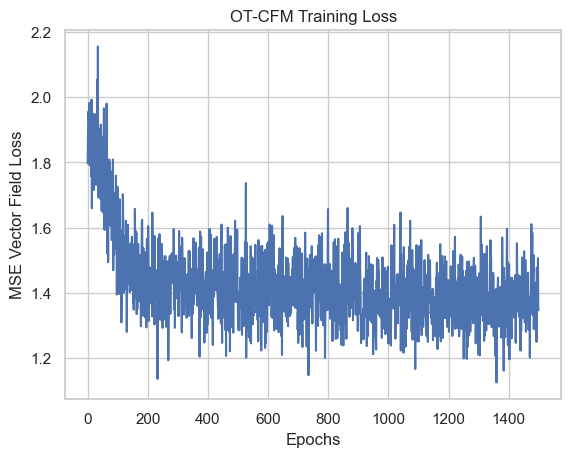

In [14]:
from sklearn.datasets import make_moons

# Gerando o Dataset Toy (Duas bacias de atração, formato "Moons")
n_samples = 2000
x1_data, _ = make_moons(n_samples=n_samples, noise=0.05)
x1_data = (x1_data - x1_data.mean(axis=0)) / x1_data.std(axis=0) # Normalize
x1_data = jnp.array(x1_data)

# Ruído Gaussiano Original (Origem do Flow)
key, subkey = random.split(key)
x0_data = random.normal(subkey, (n_samples, 2))

# Treinamento
epochs = 1500
batch_size = 256

losses = []
for epoch in range(epochs):
    # Sample aleatório do batch e tempos
    key, *subkeys = random.split(key, 4)
    idx = random.randint(subkeys[0], (batch_size,), 0, n_samples)
    
    x0_batch = x0_data[idx]
    x1_batch = x1_data[idx]
    
    # Amostrar t ~ U(0, 1)
    t_batch = random.uniform(subkeys[1], (batch_size, 1))
    
    model, opt_state, loss = make_step(model, opt_state, x0_batch, x1_batch, t_batch)
    losses.append(loss)
    
    if epoch % 300 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

plt.plot(losses)
plt.title("OT-CFM Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Vector Field Loss")
plt.show()

### 5. Inferência RW Clássica (Geração Diffrax Reversa)

Agora integramos o operador $v_\theta$ que aprendeu a apontar do ruído $x_0$ para as bacias alvo $x_1$, fazendo o rollout completo no espaço contínuo num $t \in [0, 1]$.

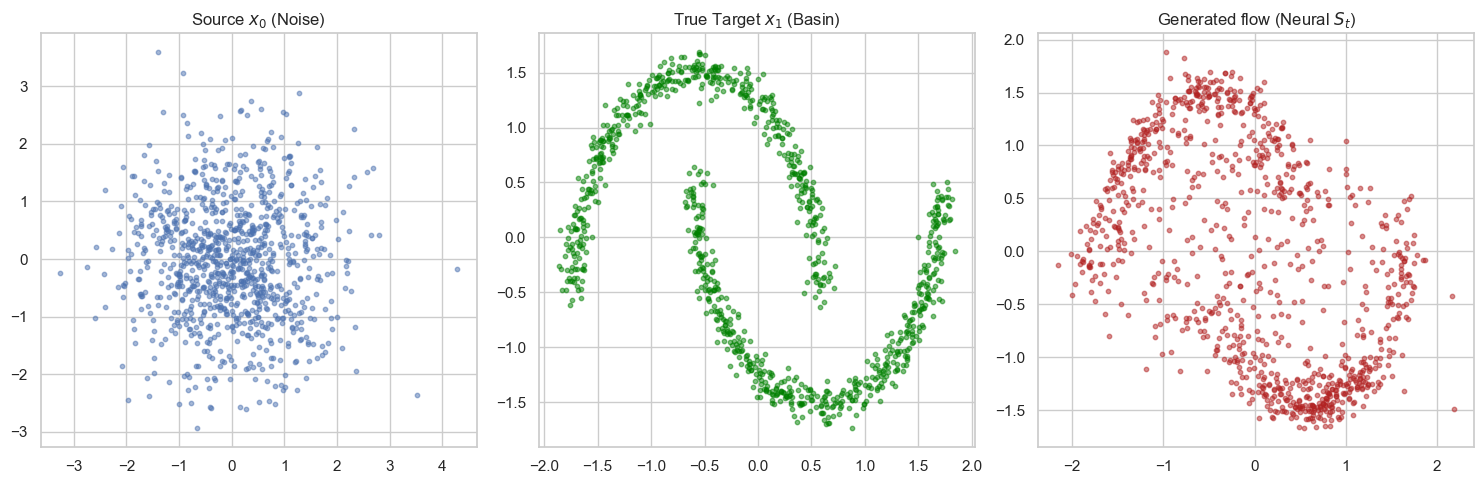

In [15]:
import diffrax

def flow_vector_field(t: float, y: jax.Array, args) -> jax.Array:
    """Wrapper the model for the diffrax API"""
    model = args
    return model(t, y)

@eqx.filter_jit
def solve_flow(model, x_initial):
    term = diffrax.ODETerm(flow_vector_field)
    solver = diffrax.Dopri5() # Runge-Kutta de alta ordem
    
    solution = diffrax.diffeqsolve(
        term,
        solver,
        t0=0.0,
        t1=1.0,
        dt0=0.1,
        y0=x_initial,
        args=model,
    )
    return solution.ys[-1]

# Gerando amostras novas a partir de Gaussian puro
key, subkey = random.split(key)
x_test_0 = random.normal(subkey, (1000, 2))

# Inferindo em Batch (JAX vmap no diffrax!)
x_test_1_pred = jax.vmap(solve_flow, in_axes=(None, 0))(model, x_test_0)

# Visualizando Output
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].scatter(x_test_0[:, 0], x_test_0[:, 1], alpha=0.5, s=10)
axs[0].set_title("Source $x_0$ (Noise)")

axs[1].scatter(x1_data[:1000, 0], x1_data[:1000, 1], alpha=0.5, s=10, color='green')
axs[1].set_title("True Target $x_1$ (Basin)")

axs[2].scatter(x_test_1_pred[:, 0], x_test_1_pred[:, 1], alpha=0.5, s=10, color='firebrick')
axs[2].set_title("Generated flow (Neural $S_t$)")

plt.tight_layout()
plt.show()